In [1]:
import sys
sys.path.append('../')

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from models.model import STGAT
from train import prepare_data, NYCTaxiDataset

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# 1. Load the new lightweight flat arrays (Sequence Length 48!)
node_features, demand_data, train_indices, test_indices, num_nodes, num_features = prepare_data('../processed/final_stgat_input.csv', seq_len=48)

# 2. Load the graph edges
adj_matrix = np.load('../processed/adjacency_matrix.npy')
edges = np.argwhere(adj_matrix == 1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
edge_index = torch.tensor(edges.T, dtype=torch.long).to(device)

# 3. Create the Test DataLoader (prevents OOM memory crashes)
test_dataset = NYCTaxiDataset(node_features, demand_data, test_indices, seq_len=48)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False) # NEVER shuffle test data!

# 4. Initialize the model and load the winning weights from the grid search
model = STGAT(in_channels=num_features, hidden_channels=64, out_channels=1, num_nodes=num_nodes).to(device)
model.load_state_dict(torch.load('../models/stgat_weights_best.pth', weights_only=True))
model.eval() # CRITICAL: turns off gradients for testing

print("\nModel and Data successfully loaded!")

Loading processed data...
Detected 263 zones and 9 weather features.
Executing chronological split (Jan-May Train / June Test)...

Model and Data successfully loaded!


In [3]:
stgat_predictions = []
baseline_predictions = []
actual_truths = []

print("Running model on June 2024 Test Data...")

with torch.no_grad():
    for batch_X, batch_Y in test_loader:
        batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)
        
        with torch.amp.autocast('cuda'):
            batch_pred = model(batch_X, edge_index)
            
        stgat_predictions.append(batch_pred.cpu().numpy())
        actual_truths.append(batch_Y.cpu().numpy())
        
        base_pred = batch_X[:, -1, :, 0:1].cpu().numpy()
        baseline_predictions.append(base_pred)

stgat_predictions = np.concatenate(stgat_predictions, axis=0)
baseline_predictions = np.concatenate(baseline_predictions, axis=0)
Y_test_numpy = np.concatenate(actual_truths, axis=0)

def calculate_metrics(pred, truth):
    mse = np.mean((pred - truth)**2)
    mae = np.mean(np.abs(pred - truth))
    return mse, mae

stgat_mse, stgat_mae = calculate_metrics(stgat_predictions, Y_test_numpy)
base_mse, base_mae = calculate_metrics(baseline_predictions, Y_test_numpy)

print(f"--- MEAN SQUARED ERROR (MSE) ---")
print(f"Naive Baseline: {base_mse:.6f}")
print(f"ST-GAT Model:   {stgat_mse:.6f}")

print(f"\n--- MEAN ABSOLUTE ERROR (MAE) ---")
print(f"Naive Baseline: {base_mae:.6f}")
print(f"ST-GAT Model:   {stgat_mae:.6f}")

Running model on June 2024 Test Data...
--- MEAN SQUARED ERROR (MSE) ---
Naive Baseline: 0.518002
ST-GAT Model:   0.326223

--- MEAN ABSOLUTE ERROR (MAE) ---
Naive Baseline: 0.463146
ST-GAT Model:   0.370359


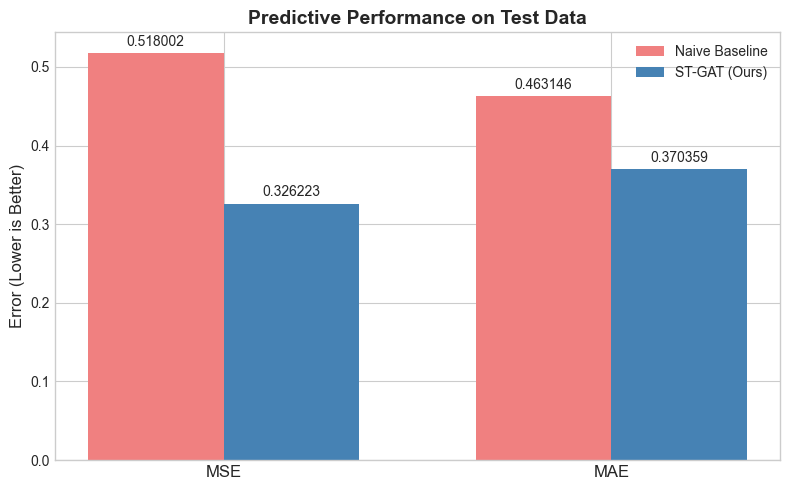

In [4]:
# --- Plotting the Chart ---
metrics = ['MSE', 'MAE']
baseline_scores = [base_mse, base_mae]
stgat_scores = [stgat_mse, stgat_mae]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, baseline_scores, width, label='Naive Baseline', color='lightcoral')
rects2 = ax.bar(x + width/2, stgat_scores, width, label='ST-GAT (Ours)', color='steelblue')

ax.set_ylabel('Error (Lower is Better)', fontsize=12)
ax.set_title('Predictive Performance on Test Data', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.legend()

for rect in rects1 + rects2:
    height = rect.get_height()
    # Updated to 6 decimal places here!
    ax.annotate(f'{height:.6f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

Running Permutation Feature Importance...
Scrambling feature index 0...
Scrambling feature index 1...
Scrambling feature index 2...
Scrambling feature index 3...
Scrambling feature index 4...
Scrambling feature index 5...
Scrambling feature index 6...
Scrambling feature index 7...
Scrambling feature index 8...
Scrambling feature index 9...


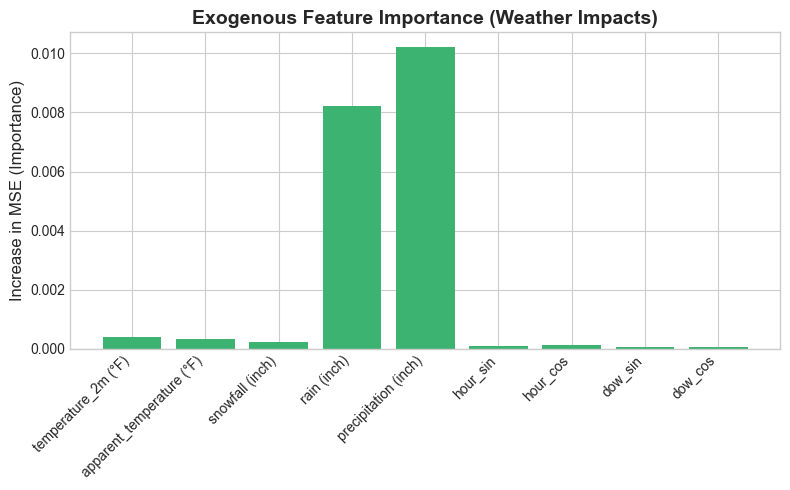

In [18]:
# Permutation Feature Importance
print("Running Permutation Feature Importance...")

importance_scores = []
base_mse, _ = calculate_metrics(stgat_predictions, Y_test_numpy)

for feature_idx in range(num_features):
    print(f"Scrambling feature index {feature_idx}...")
    
    # 1. Create a fresh copy of the node_features array
    temp_node_features = node_features.copy()
    
    # 2. Shuffle the specific feature across the entire timeline
    feature_data = temp_node_features[:, :, feature_idx].flatten()
    np.random.shuffle(feature_data)
    temp_node_features[:, :, feature_idx] = feature_data.reshape(temp_node_features[:, :, feature_idx].shape)
    
    # 3. Create a temporary Dataset and DataLoader with the scrambled data
    temp_dataset = NYCTaxiDataset(temp_node_features, demand_data, test_indices, seq_len=48)
    temp_loader = DataLoader(temp_dataset, batch_size=32, shuffle=False)
    
    # 4. Run predictions on the scrambled data
    scrambled_preds = []
    with torch.no_grad():
        for batch_X, _ in temp_loader:
            batch_X = batch_X.to(device)
            with torch.amp.autocast('cuda'):
                batch_pred = model(batch_X, edge_index)
            scrambled_preds.append(batch_pred.cpu().numpy())
            
    scrambled_preds = np.concatenate(scrambled_preds, axis=0)
    
    # 5. Calculate how much the error increased
    scrambled_mse, _ = calculate_metrics(scrambled_preds, Y_test_numpy)
    importance = scrambled_mse - base_mse
    importance_scores.append(importance)

# Get feature names dynamically
df_temp = pd.read_csv('../processed/final_stgat_input.csv', index_col=0, nrows=0)
weather_cols = [c for c in df_temp.columns if not c.isdigit()]
feature_names = ['Past Demand'] + weather_cols

fig, ax = plt.subplots(figsize=(8, 5))

# Exclude "Past Demand" from the chart to focus just on Weather features
weather_features = feature_names[1:]
weather_importances = importance_scores[1:]

ax.bar(weather_features, weather_importances, color='mediumseagreen')
ax.set_ylabel('Increase in MSE (Importance)', fontsize=12)
ax.set_title('Exogenous Feature Importance (Weather Impacts)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()